# Uplift Modeling & Bayesian Inference (MCMC)
## Step 1: Data Cleaning, Categorical Encoding, and Feature Standardization

In this notebook, we prepare the marketing dataset for Bayesian Logistic Regression via MCMC:
1. **Loading and Integrity Checks**: Inspect dataset shape, data types, and check for missing values.
2. **Categorical / Text Feature Encoding**:
   - `offer` (Treatment): Mapped both as an integer index (`offer_idx`: 0 = No Offer, 1 = BOGO, 2 = Discount) for vector indexing in PyMC, and as binary dummy variables.
   - `zip_code` and `channel` (Confounders): Encoded into binary dummies using reference baseline categories to prevent multicollinearity.
3. **Continuous Feature Transformation & Standardization**:
   - `history` (Past spend): Log-transformed via $\log(\text{history})$ to handle right-skewness, followed by Z-score standardization.
   - `recency` (Months since last order): Standardized via linear Z-score.
4. **Export**: Save the cleaned and standardized dataset to `data_processed.csv`.

In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Plotting configuration
plt.rcParams["figure.figsize"] = (10, 5)
print("Libraries successfully imported")

Libraries successfully imported!


In [2]:
# 2. Load the raw dataset
df = pd.read_csv("data.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("Missing values per column:")
print(df.isnull().sum())
df.head()

Dataset shape: 64000 rows x 9 columns
Missing values per column:
recency          0
history          0
used_discount    0
used_bogo        0
zip_code         0
is_referral      0
channel          0
offer            0
conversion       0
dtype: int64


,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
3,9,675.83,1,0,Rural,1,Web,Discount,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0


In [6]:
# 3. Encoding Categorical / String Variables

# A) Treatment variable (offer)
# Create an integer index (0: Control/No Offer, 1: BOGO, 2: Discount)
offer_mapping = {'No Offer': 0, 'Buy One Get One': 1, 'Discount': 2}
df['offer_idx'] = df['offer'].map(offer_mapping)

# B) Confounders: zip_code and channel
# zip_code: Suburban is reference baseline, creating Urban and Rural dummies
df['zip_urban'] = (df['zip_code'] == 'Urban').astype(int)
df['zip_rural'] = (df['zip_code'] == 'Rural').astype(int)

# channel: Web is reference baseline, creating Phone and Multichannel dummies
df['channel_phone'] = (df['channel'] == 'Phone').astype(int)
df['channel_multichannel'] = (df['channel'] == 'Multichannel').astype(int)

print("Distribution of offer_idx:")
print(df['offer_idx'].value_counts().sort_index())
df.head()

Distribution of offer_idx:
offer_idx
0    21306
1    21387
2    21307
Name: count, dtype: int64


,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion,offer_idx,zip_urban,zip_rural,channel_phone,channel_multichannel,log_history,recency_scaled,history_scaled
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0,1,0,0,1,0,4.958921,1.207751,-0.035767
1,6,329.08,1,1,Rural,1,Web,No Offer,0,0,0,1,0,0,5.796301,0.067359,0.778130
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0,1,0,0,0,0,5.196561,0.352457,0.195209
3,9,675.83,1,0,Rural,1,Web,Discount,0,2,0,1,0,0,6.515942,0.922653,1.477590
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0,1,1,0,0,0,3.814190,-1.073034,-1.148396


In [7]:
# Verify zero-count in history (check if any customer has zero spend before log-transform)
zero_history_count = (df['history'] == 0).sum()
print(f"Customers with history == 0: {zero_history_count}")

Customers with history == 0: 0


In [8]:
# 4. Continuous Feature Transformation & Standardization

# History has strong right-skewness: apply natural logarithm log(history) to normalize
df['log_history'] = np.log(df['history'])

# Standardize continuous variables (mean = 0, std = 1) using Z-score
# This ensures smooth MCMC geometry and comparable prior distributions
scaler = StandardScaler()
df[['recency_scaled', 'history_scaled']] = scaler.fit_transform(df[['recency', 'log_history']])

print("Summary statistics of standardized variables:")
print(df[['recency_scaled', 'history_scaled']].describe().round(3))

Summary statistics of standardized variables:
       recency_scaled  history_scaled
count       64000.000       64000.000
mean           -0.000           0.000
std             1.000           1.000
min            -1.358          -1.550
25%            -1.073          -0.803
50%             0.067           0.066
75%             0.923           0.768
max             1.778           3.032


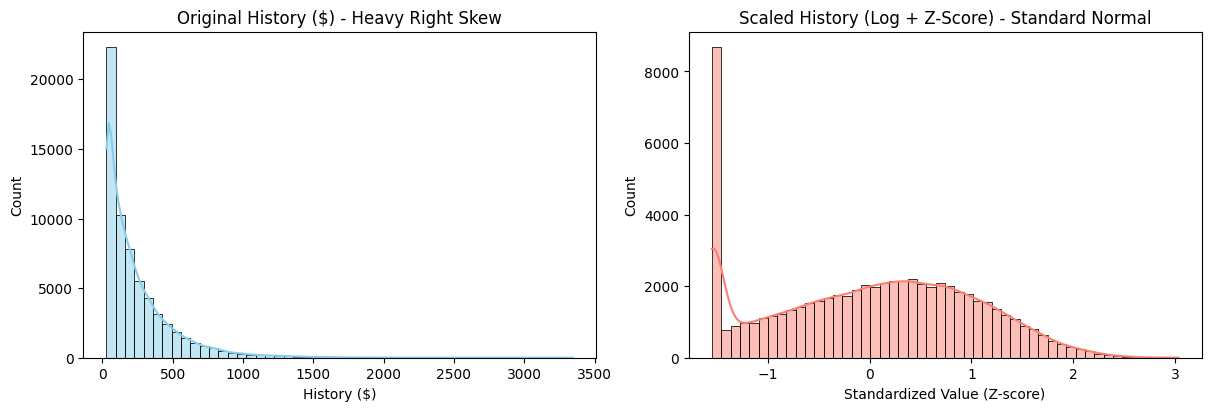

In [9]:
# 5. Visual Inspection: Distribution Before and After Transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

sns.histplot(df['history'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title("Original History ($) - Heavy Right Skew")
axes[0].set_xlabel("History ($)")

sns.histplot(df['history_scaled'], bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title("Scaled History (Log + Z-Score) - Standard Normal")
axes[1].set_xlabel("Standardized Value (Z-score)")

plt.show()

In [ ]:
# 6. Final Feature Selection and Export
# Select only numeric features required for PyMC Bayesian modeling
feature_cols = [
    'conversion',          # Binary target: 1 = purchased, 0 = did not purchase
    'offer_idx',           # Treatment index: 0 = No Offer, 1 = BOGO, 2 = Discount     
    'recency_scaled',      # Standardized recency
    'history_scaled',      # Standardized log(history)
    'used_discount',       # Historical discount usage flag
    'used_bogo',           # Historical BOGO usage flag
    'is_referral',         # Referral acquisition flag
    'zip_urban',           # Urban location dummy (Suburban baseline)
    'zip_rural',           # Rural location dummy (Suburban baseline)
    'channel_phone',       # Phone channel dummy (Web baseline)
    'channel_multichannel' # Multichannel dummy (Web baseline)
]

df_processed = df[feature_cols].copy()
df_processed.to_csv("data_processed.csv", index=False)
print(f"File 'data_processed.csv' successfully saved. Shape: {df_processed.shape}")
df_processed.head(15)

File 'data_processed.csv' successfully saved! Shape: (64000, 11)


,conversion,offer_idx,recency_scaled,history_scaled,used_discount,used_bogo,is_referral,zip_urban,zip_rural,channel_phone,channel_multichannel
0,0,1,1.207751,-0.035767,1,0,0,0,0,1,0
1,0,0,0.067359,0.778130,1,1,1,0,1,0,0
2,0,1,0.352457,0.195209,0,1,1,0,0,0,0
3,0,2,0.922653,1.477590,1,0,1,0,1,0,0
4,0,1,-1.073034,-1.148396,1,0,0,1,0,0,0
5,1,1,0.067359,-0.089133,0,1,0,0,0,1,0
6,0,1,0.922653,0.621842,1,0,1,0,0,1,0
7,0,1,0.922653,-1.125515,0,1,0,1,0,1,0
8,0,2,0.922653,1.476496,1,1,1,0,1,1,0
9,0,1,1.207751,-1.461893,0,1,1,1,0,0,0
